**Code Example 1: Face Detection Using Haar Cascade**

Upload an image with at least one human face (jpg, png):


Saving jm.jpg to jm.jpg
Number of faces detected: 1


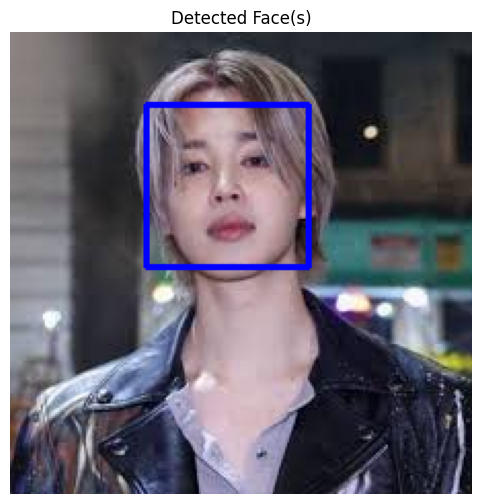

In [1]:
# Install OpenCV (headless version for Colab)
!pip install opencv-python-headless --quiet

import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Step 1: Upload a face image
print("Upload an image with at least one human face (jpg, png):")
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Step 2: Load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Step 3: Read image and convert to grayscale
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 4: Detect faces
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print("Number of faces detected:", len(faces))

# Step 5: Draw rectangles around detected faces
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

# Step 6: Convert BGR to RGB for matplotlib display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 7: Display result
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Detected Face(s)")
plt.axis('off')
plt.show()

**Code Example 2: Real-Time Face Detection with Webcam**

Upload a video file (e.g., .mp4, .avi):


Saving video2.mp4 to video2.mp4


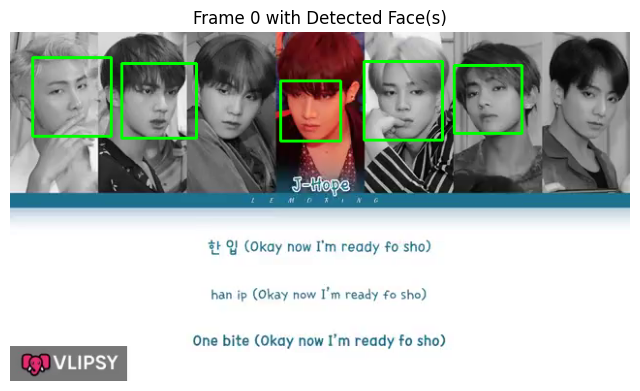

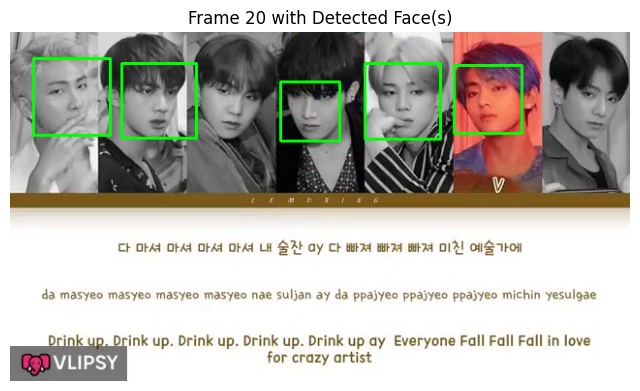

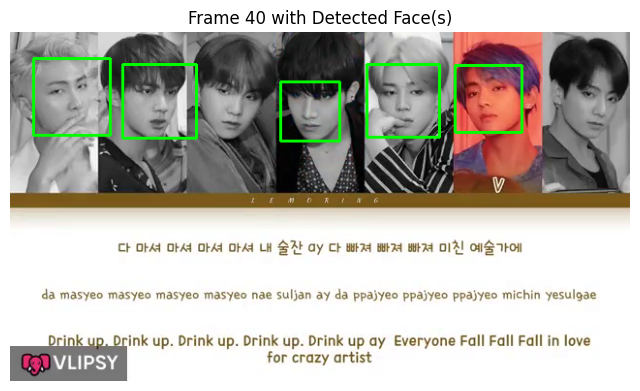

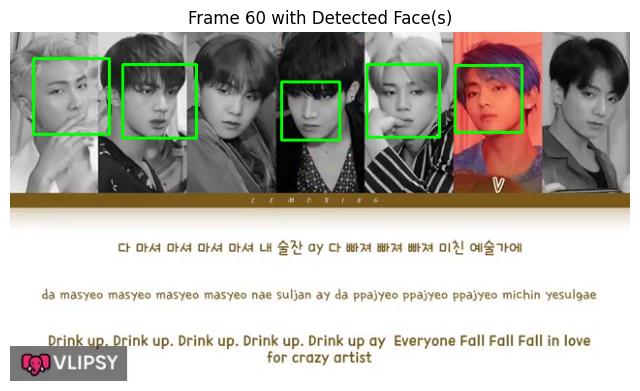

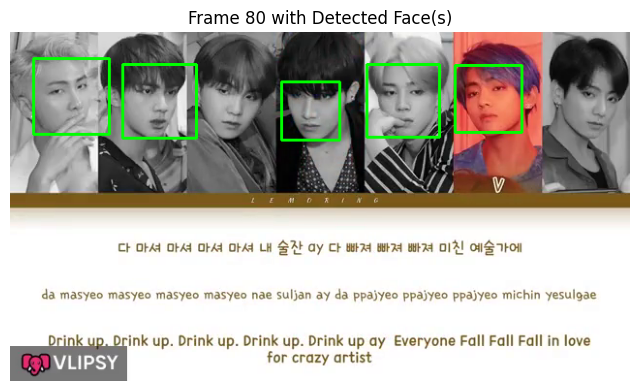

Processing finished.


In [2]:
# Install OpenCV
!pip install opencv-python-headless --quiet

import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Step 1: Upload a short video with a human face
print("Upload a video file (e.g., .mp4, .avi):")
uploaded = files.upload()

video_path = list(uploaded.keys())[0]

# Step 2: Load the Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Step 3: Read video file
cap = cv2.VideoCapture(video_path)

frame_count = 0
max_frames = 100   # limit frames to avoid long runtime

while True:
    ret, frame = cap.read()

    if not ret or frame_count >= max_frames:
        break

    # Convert frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(30, 30)
    )

    # Draw rectangles around faces
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # Convert BGR to RGB for matplotlib
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Display every 20th frame
    if frame_count % 20 == 0:
        plt.figure(figsize=(8,5))
        plt.imshow(rgb)
        plt.title(f"Frame {frame_count} with Detected Face(s)")
        plt.axis('off')
        plt.show()

    frame_count += 1

# Release video capture
cap.release()

print("Processing finished.")

**Case Study 1: Automated Celebrity Face Recognition for Media Archiving**

In [3]:
# Install OpenCV with face module
!pip install opencv-contrib-python --quiet

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def load_dataset(dataset_path):
    images = []
    labels = []
    label_dict = {}
    current_label = 0

    for person_name in os.listdir(dataset_path):

        person_path = os.path.join(dataset_path, person_name)

        if os.path.isdir(person_path):

            label_dict[current_label] = person_name

            for img_name in os.listdir(person_path):

                img_path = os.path.join(person_path, img_name)

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                # Check if image is valid
                if img is not None:

                    img = cv2.resize(img, (200, 200))  # keep same size

                    images.append(img)
                    labels.append(current_label)

                else:
                    print("Failed to load image:", img_path)

            current_label += 1

    return images, labels, label_dict

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
dataset_path = "/content/drive/MyDrive/clebs"

In [9]:
images, labels, label_dict = load_dataset(dataset_path)

print("Total images:", len(images))
print("Total persons:", len(label_dict))

Total images: 4
Total persons: 2


In [10]:
recognizer = cv2.face.LBPHFaceRecognizer_create()

recognizer.train(images, np.array(labels))

recognizer.save("/content/face_recognizer.yml")

print("Model trained successfully")

Model trained successfully


In [11]:
with open("/content/label_map.txt", "w") as f:
    for label, name in label_dict.items():
        f.write(f"{label}:{name}\n")

In [12]:
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.read("/content/face_recognizer.yml")

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [13]:
label_map = {}

with open("/content/label_map.txt", "r") as f:
    for line in f:
        label, name = line.strip().split(":")
        label_map[int(label)] = name

In [14]:
from google.colab import files

uploaded = files.upload()

test_image = list(uploaded.keys())[0]

Saving v.jpg to v.jpg


In [15]:
img = cv2.imread(test_image)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

for (x, y, w, h) in faces:

    roi_gray = gray[y:y+h, x:x+w]

    roi_gray = cv2.resize(roi_gray, (200,200))

    label, confidence = recognizer.predict(roi_gray)

    name = label_map.get(label, "Unknown")

    cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)

    cv2.putText(img,
                f"{name} ({int(confidence)})",
                (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0,255,0),
                2)

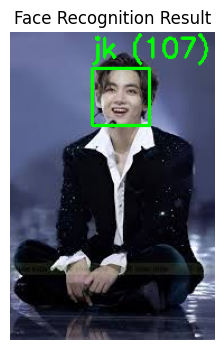

In [17]:
plt.figure(figsize=(5,4))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.title("Face Recognition Result")

plt.show()

**Case Study 2: Face Unlock in Smartphones**

In [21]:
# Install OpenCV with face module
!pip install opencv-contrib-python --quiet

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [22]:
# Step 2: Upload test image (to unlock)
print("Upload the test image (to verify identity):")
uploaded_test = files.upload()
test_image_path = list(uploaded_test.keys())[0]


Upload the test image (to verify identity):


Saving a1.jpg to a1 (1).jpg


In [23]:
# Step 2: Upload test image (to unlock)
print("Upload the test image (to verify identity):")
uploaded_test = files.upload()
test_image_path = list(uploaded_test.keys())[0]


Upload the test image (to verify identity):


Saving a2.jpg to a2 (1).jpg
